In [1]:
import pandas as pd
import os

In [2]:
base_df = pd.read_csv('../data/data_final_with_aadt_and_vulnerability.csv')

base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]
scenario_results = {}

# STAP 1: Eerst alle data verzamelen en de ruwe impact berekenen
all_dfs = []
for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'
    scenario_df = pd.read_csv(file_path)

    merged_df = pd.merge(
        scenario_df[['Seed', 'Total_Delay']],
        base_subset,
        left_on='Seed',
        right_on='id'
    ).drop(columns=['Seed'])[['id', 'Total_Delay', 'avg_truck_AADT', 'lat', 'lon']]

    # Bereken de ruwe impact (Delay * Trucks)
    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']
    merged_df['scenario_id'] = i  # Handig om later te weten welk scenario dit was

    all_dfs.append(merged_df)

# STAP 2: Bereken de globale Min en Max over alle 12 scenario's heen
combined_data = pd.concat(all_dfs)
global_min = combined_data['impact_raw'].min()
global_max = combined_data['impact_raw'].max()

# STAP 3: De scaling toepassen en de resultaten opslaan
for i, df in enumerate(all_dfs):
    # Pas de scaling toe op basis van de globale uitersten
    df['impact_scaled'] = (df['impact_raw'] - global_min) / (global_max - global_min)

    # Sorteer zodat de meest kritieke punten (top 20) bovenaan staan
    #df = df.sort_values(by='impact_scaled', ascending=False)

    # Sla op in dictionary en als losse variabelen (df_0, df_1, etc.)
    scenario_results[f'scenario_{i}'] = df
    globals()[f'df_{i}'] = df

print(f"Check: df_0 is klaar. Globale max was {global_max:.2f}")
print(df_0[['id', 'impact_raw', 'impact_scaled']].head(5))

Check: df_0 is klaar. Globale max was 32100463.22
       id    impact_raw  impact_scaled
0  100009  6.314906e+06       0.196493
1  100015  6.372160e+06       0.198277
2  100057  9.329203e+06       0.290422
3  100061  2.314534e+07       0.720948
4  100077  9.793418e+06       0.304887


In [3]:
#aantal rijen die je hebt is aantal bruggen die kapot zijn gegaan
count_bridges = len(base_df[base_df['model_type'] == 'bridge'])

print(f"Amount bridges: {count_bridges}")

Amount bridges: 1434


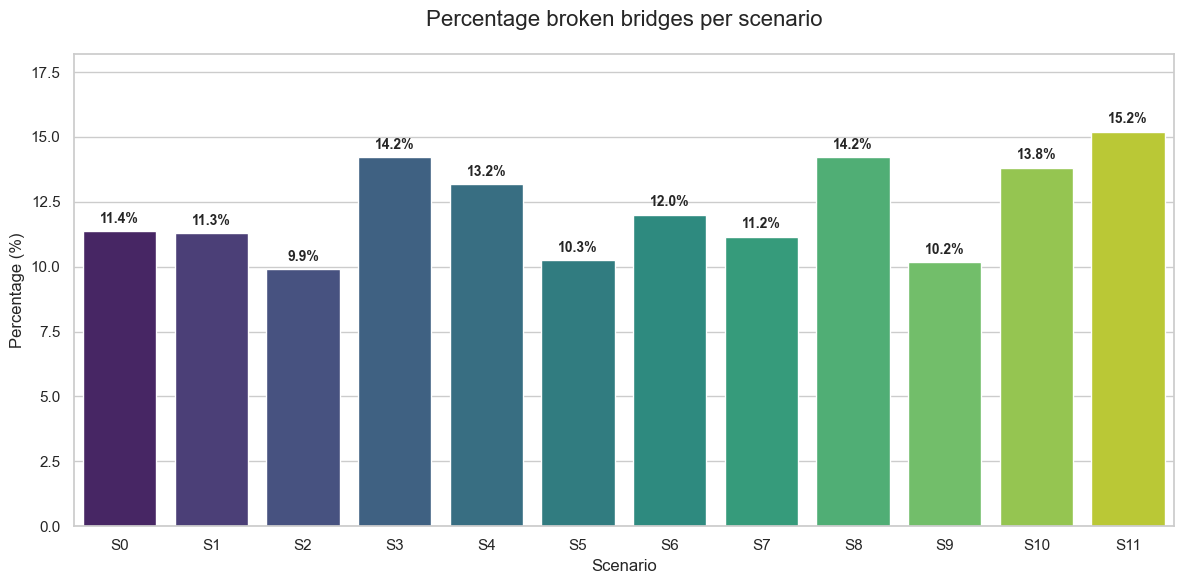

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

scenarios = [df_0, df_1, df_2, df_3, df_4, df_5, df_6, df_7, df_8, df_9, df_10, df_11]

# Bereken percentages en maak labels
percentages = [(len(df) / count_bridges) * 100 for df in scenarios]
labels = [f"S{i}" for i in range(len(scenarios))]

# Maak een DataFrame die Seaborn begrijpt
plot_df = pd.DataFrame({
    'Scenario': labels,
    'Percentage': percentages
})

# 2. Plotten
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Maak de bar chart
ax = sns.barplot(x='Scenario', y='Percentage', data=plot_df, palette='viridis', hue='Scenario', legend=False)

# 3. Styling en labels
plt.title('Percentage broken bridges per scenario', fontsize=16, pad=20)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Scenario', fontsize=12)
plt.ylim(0, max(percentages) + 3) # Extra ruimte bovenin voor de tekst

# Voeg de tekstlabels (de cijfers) boven de balken toe
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
combined_df = pd.concat(scenarios)

avg_impact_per_bridge = combined_df.groupby('id').agg({
    'impact_scaled': 'mean',
    'impact_raw': 'mean',
    'avg_truck_AADT': 'first',
    'lat': 'first',
    'lon': 'first',
    'scenario_id': lambda x: list(x)
}).rename(columns={'scenario_id': 'scenarios_found'})

avg_impact_per_bridge['occurrence_count'] = avg_impact_per_bridge['scenarios_found'].apply(len)

avg_impact_per_bridge = avg_impact_per_bridge.sort_values(by='impact_scaled', ascending=False)

print("Top 20 most critical bridges:")

avg_impact_per_bridge[['impact_scaled', 'occurrence_count', 'scenarios_found']].head(20)

Top 20 most critical bridges:


,impact_scaled,occurrence_count,scenarios_found
id,,,
100139,0.850423,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100141,0.834198,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100145,0.820455,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100067,0.755383,6,"[3, 4, 6, 8, 10, 11]"
100231,0.745372,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100061,0.722557,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100085,0.700958,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100101,0.681019,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100359,0.556730,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


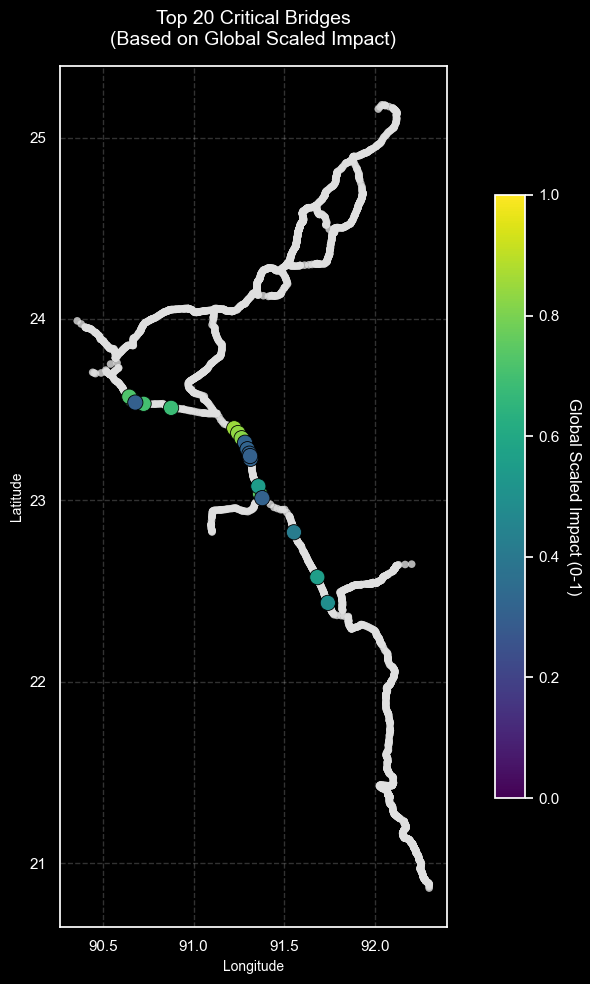

In [13]:
import matplotlib.pyplot as plt

top_20_df = avg_impact_per_bridge.head(20).copy().reset_index()

fig, ax = plt.subplots(figsize=(10, 10))

#layer1
ax.scatter(base_df['lon'], base_df['lat'],
           color='#e0e0e0',
           s=30,
           alpha=0.8,
           edgecolor='none',
           zorder=1)

#layer2 most critical bridges
sc = ax.scatter(top_20_df['lon'], top_20_df['lat'],
                c=top_20_df['impact_scaled'],
                cmap='viridis',
                s=120,
                alpha=1.0,
                edgecolor='black',
                linewidth=0.6,
                zorder=2)


#Styling & Labels
ax.set_title("Top 20 Critical Bridges\n(Based on Global Scaled Impact)", fontsize=14, pad=15)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.set_aspect('equal', adjustable='box')

ax.grid(True, linestyle='--', alpha=0.2)

#colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Global Scaled Impact (0-1)', rotation=270, labelpad=15)
sc.set_clim(0, 1) # Forceert de kleurenbalk om de volledige schaal te tonen

plt.tight_layout()

# Optioneel: Opslaan voor je verslag
# plt.savefig('top_20_critical_bridges_honest.png', dpi=300, bbox_inches='tight')

plt.show()

In [15]:
totaal_scenarios = 12
avg_impact_per_bridge['expected_impact'] = (
    avg_impact_per_bridge['impact_scaled'] * (avg_impact_per_bridge['occurrence_count'] / totaal_scenarios)
)

top_20_expected = avg_impact_per_bridge.sort_values(by='expected_impact', ascending=False).head(20).copy()


print("Top 20 Bruggen op basis van Expected Impact (Gecorrigeerd):")
print("-" * 85)
display_cols = ['impact_scaled', 'occurrence_count', 'expected_impact', 'lat', 'lon']
top_20_expected[display_cols].reset_index()

Top 20 Bruggen op basis van Expected Impact (Gecorrigeerd):
-------------------------------------------------------------------------------------


,id,impact_scaled,occurrence_count,expected_impact,lat,lon
0,100139,0.850423,12,0.850423,23.397652,91.223422
1,100141,0.834198,12,0.834198,23.371365,91.245018
2,100145,0.820455,12,0.820455,23.342671,91.264486
3,100231,0.745372,12,0.745372,23.037973,91.365678
4,100061,0.722557,12,0.722557,23.571631,90.645416
5,100085,0.700958,12,0.700958,23.532419,90.724281
6,100101,0.681019,12,0.681019,23.510088,90.875720
7,100359,0.556730,12,0.556730,22.576793,91.681623
8,100225,0.549709,12,0.549709,23.077965,91.356601
9,100283,0.414892,12,0.414892,22.824371,91.552692


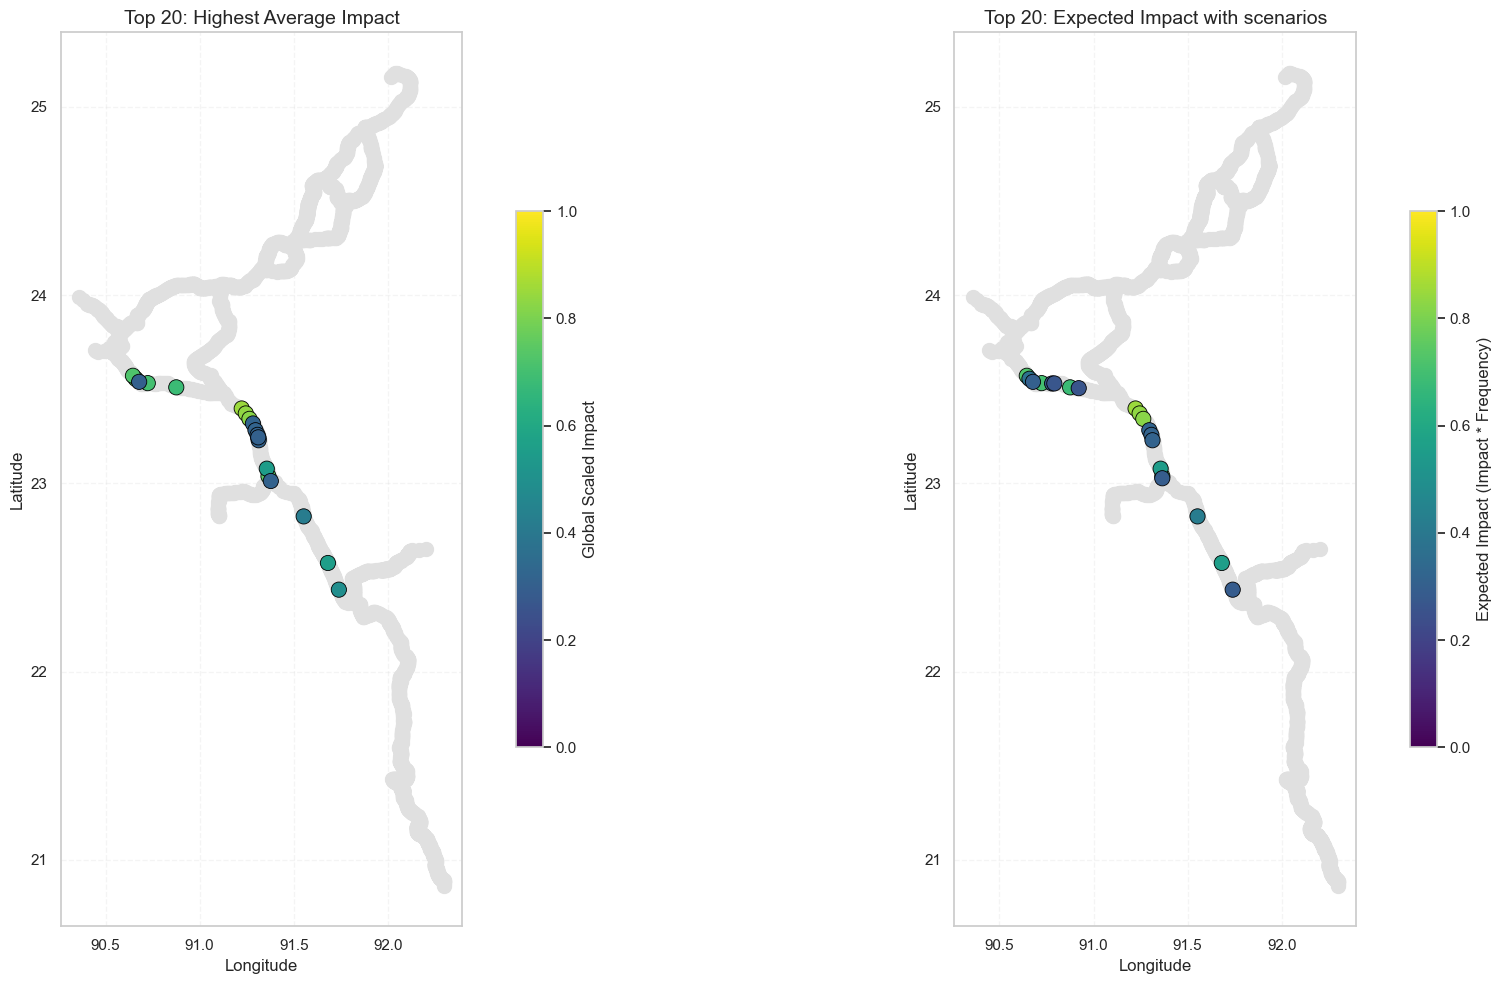

In [35]:
import matplotlib.pyplot as plt

top_20_impact = avg_impact_per_bridge.sort_values('impact_scaled', ascending=False).head(20).reset_index()

top_20_expected = avg_impact_per_bridge.sort_values('expected_impact', ascending=False).head(20).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))


ax1 = axes[0]
ax1.scatter(base_df['lon'], base_df['lat'], color= '#e0e0e0', s=100, alpha=1, zorder=1) # s verlaagd naar 2 voor context
sc1 = ax1.scatter(top_20_impact['lon'], top_20_impact['lat'],
                  c=top_20_impact['impact_scaled'], cmap='viridis',
                  s=120, alpha=1.0, edgecolor='black', linewidth=0.6, zorder=2)

ax1.set_title("Top 20: Highest Average Impact", fontsize=14)
sc1.set_clim(0, 1)
plt.colorbar(sc1, ax=ax1, shrink=0.6, label='Global Scaled Impact')

# --- RECHTER PLOT: Expected Impact (Gecorrigeerd) ---
ax2 = axes[1]
ax2.scatter(base_df['lon'], base_df['lat'], color='#e0e0e0', s=100, alpha=1, zorder=1)
sc2 = ax2.scatter(top_20_expected['lon'], top_20_expected['lat'],
                  c=top_20_expected['expected_impact'], cmap='viridis',
                  s=120, alpha=1.0, edgecolor='black', linewidth=0.6, zorder=2)

ax2.set_title("Top 20: Expected Impact with scenarios", fontsize=14)
sc2.set_clim(0, 1)
plt.colorbar(sc2, ax=ax2, shrink=0.6, label='Expected Impact (Impact * Frequency)')

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

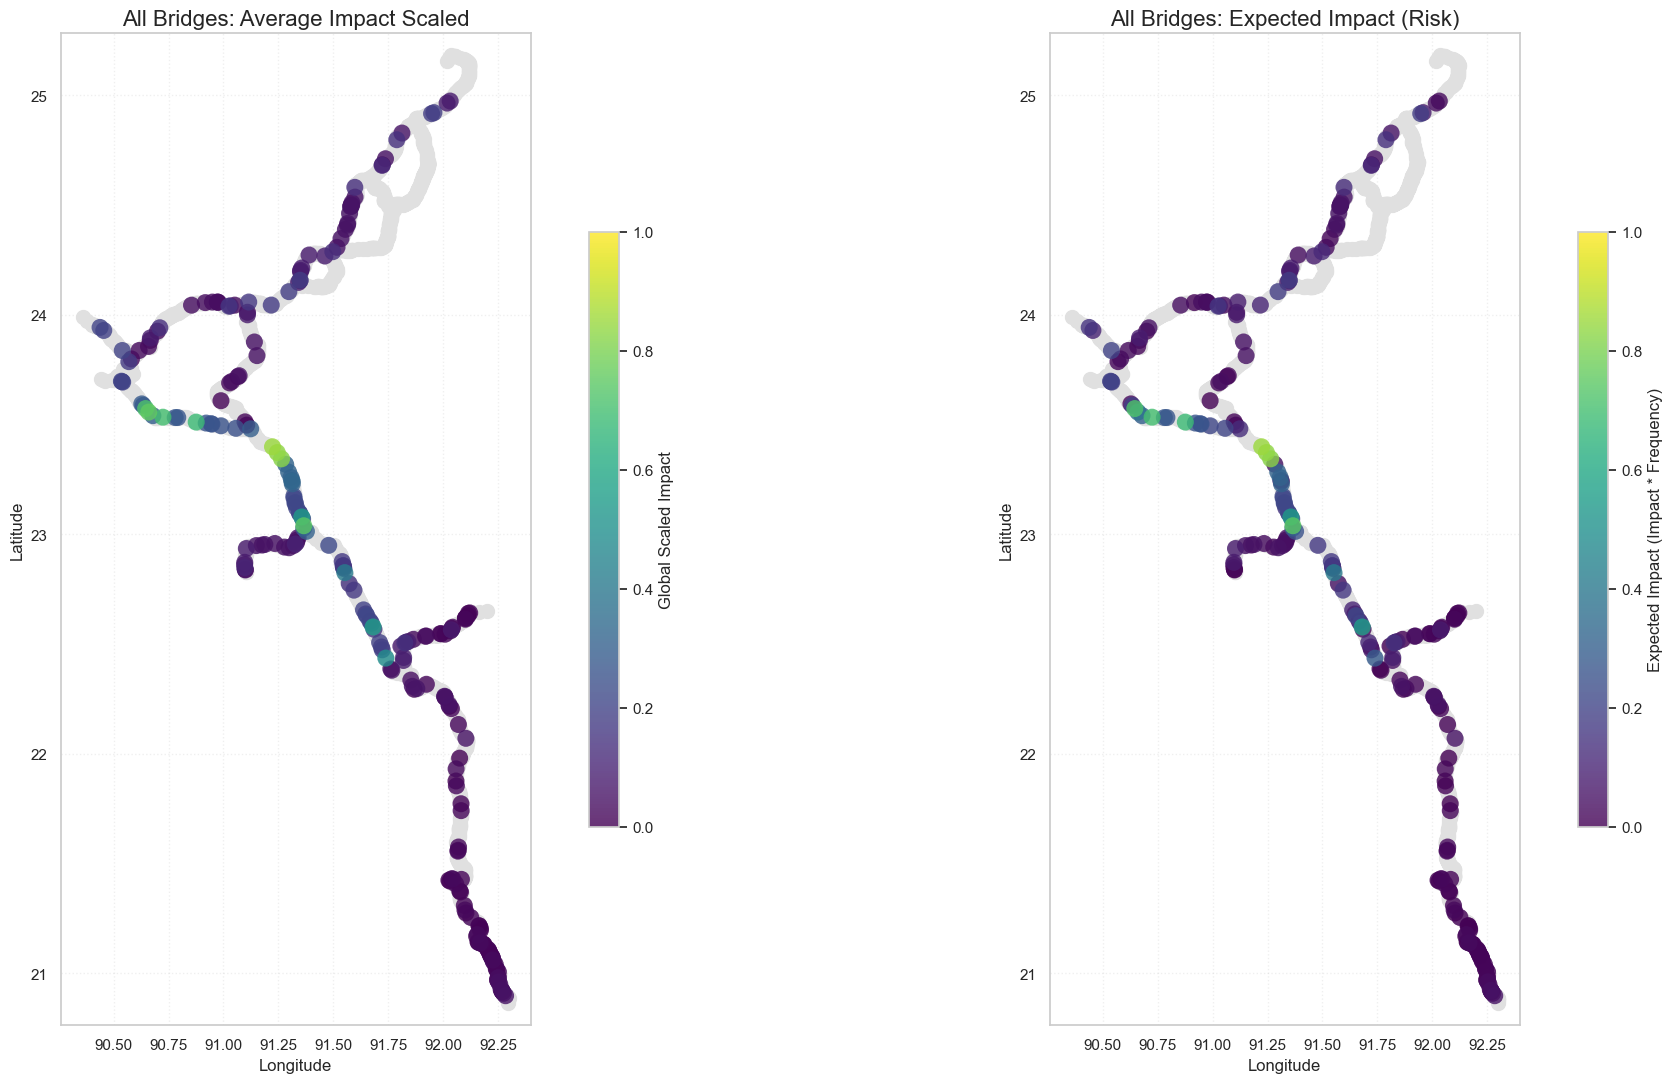

In [34]:
import matplotlib.pyplot as plt

# 1. De volledige data voorbereiden
# We sorteren op de waarde die we plotten zodat de hoogste waarden 'bovenop' liggen
all_bridges_impact = avg_impact_per_bridge.sort_values('impact_scaled', ascending=True).reset_index()
all_bridges_expected = avg_impact_per_bridge.sort_values('expected_impact', ascending=True).reset_index()

# 2. Subplots maken
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

# --- LINKER PLOT: Alle Bruggen - Gemiddelde Impact ---
ax1 = axes[0]
# Wegennet op achtergrond (erg klein en licht)
ax1.scatter(base_df['lon'], base_df['lat'], color= '#e0e0e0', s=100, alpha=1, zorder=1)

# Alle bruggen
sc1 = ax1.scatter(all_bridges_impact['lon'], all_bridges_impact['lat'],
                  c=all_bridges_impact['impact_scaled'],
                  cmap='viridis',
                  s=150,          # Iets kleiner vanwege de hoeveelheid
                  alpha=0.8,
                  edgecolor='none',
                  zorder=2)

ax1.set_title("All Bridges: Average Impact Scaled", fontsize=16)
sc1.set_clim(0, 1)
plt.colorbar(sc1, ax=ax1, shrink=0.6, label='Global Scaled Impact')

# --- RECHTER PLOT: Alle Bruggen - Expected Impact ---
ax2 = axes[1]
ax2.scatter(base_df['lon'], base_df['lat'], color='#e0e0e0', s=100, alpha=1, zorder=1)

sc2 = ax2.scatter(all_bridges_expected['lon'], all_bridges_expected['lat'],
                  c=all_bridges_expected['expected_impact'],
                  cmap='viridis',
                  s=150,
                  alpha=0.8,
                  edgecolor='none',
                  zorder=2)

ax2.set_title("All Bridges: Expected Impact (Risk)", fontsize=16)
sc2.set_clim(0, 1)
plt.colorbar(sc2, ax=ax2, shrink=0.6, label='Expected Impact (Impact * Frequency)')

# --- STYLING ---
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal', adjustable='box')

    # Gebruik de volledige dataset voor de grenzen
    ax.set_xlim(base_df['lon'].min() - 0.1, base_df['lon'].max() + 0.1)
    ax.set_ylim(base_df['lat'].min() - 0.1, base_df['lat'].max() + 0.1)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_facecolor('white') # Zorg voor een schone witte achtergrond

plt.tight_layout()
plt.show()